Shape of data: (1137, 43)
Columns: Index(['id', 'magnitude', 'type', 'title', 'date', 'time', 'updated', 'url',
       'detailUrl', 'felt', 'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig',
       'net', 'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms', 'gap',
       'magType', 'geometryType', 'depth', 'latitude', 'longitude', 'place',
       'distanceKM', 'placeOnly', 'location', 'continent', 'country',
       'subnational', 'city', 'locality', 'postcode', 'what3words', 'timezone',
       'locationDetails'],
      dtype='object')
           id  magnitude        type  \
0  us7000necw        4.8  earthquake   
1  tx2024shcj        5.1  earthquake   
2  ci40734823        3.7  earthquake   
3  tx2024scvz        3.9  earthquake   
4  us7000ndte        4.1  earthquake   

                                        title                 date  \
0         M 4.8 - 33 km WSW of Ackerly, Texas  2024-09-17T00:49:42   
1         M 5.1 - 34 km WSW of Ackerly, Texas  2024-09-17T00:49:42   
2   

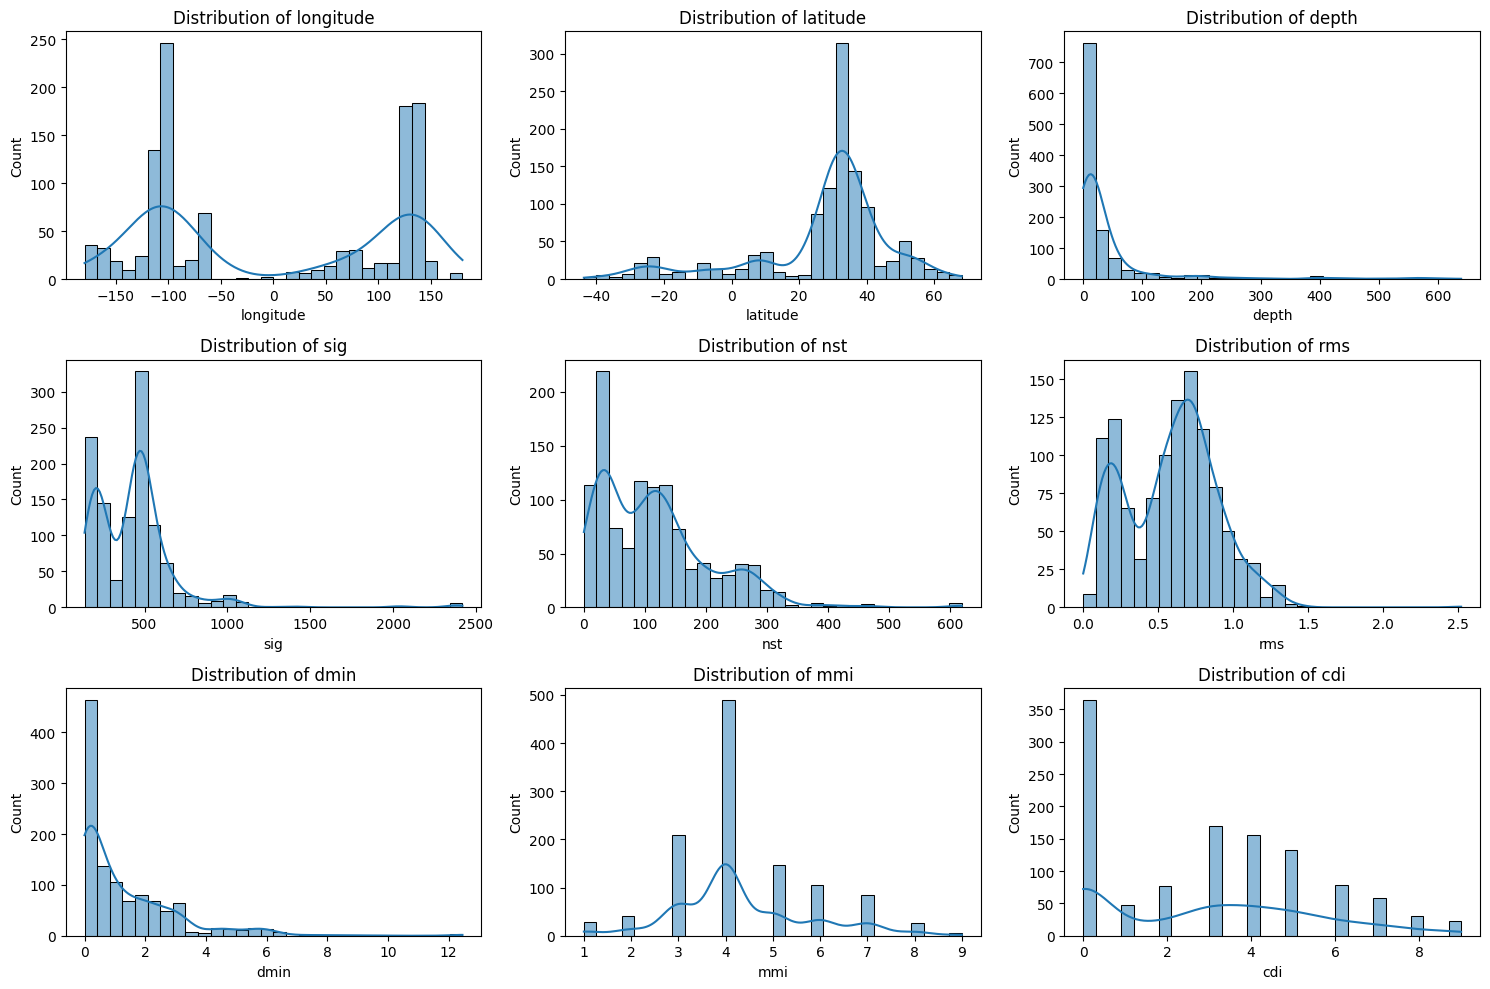

Value counts for alert:
 alert
green      711
unknown    373
yellow      38
red          9
orange       6
Name: count, dtype: int64
Value counts for status:
 status
reviewed     1127
automatic       6
REVIEWED        4
Name: count, dtype: int64
Value counts for magType:
 magType
mww      551
ml       351
mb       124
mwr       53
mw        36
mb_lg     16
mwb        2
Ml         2
Mi         2
Name: count, dtype: int64
Value counts for continent:
 continent
North America      446
Asia               333
unknown            270
South America       75
Europe               7
Africa               3
Insular Oceania      1
Insluar Oceania      1
Oceania              1
Name: count, dtype: int64
Linear Regression - MAE: 0.1931938015368052 MSE: 0.06774367360699038
Random Forest - MAE: 0.037837719298247585 MSE: 0.007298419736842115
Le modèle Random Forest est le meilleur.


In [1]:
# Importer les bibliothèques nécessaires
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chargement et exploration des données
data = pd.read_csv('../data/earthquakes.csv')

# Afficher un aperçu des données
print("Shape of data:", data.shape)
print("Columns:", data.columns)
print(data.head())
print(data.info())

# 2. Prétraitement des données
# Colonnes sélectionnées
selected_columns = [
    'magnitude', 'longitude', 'latitude', 'depth', 'sig', 'nst', 'rms',
    'dmin', 'mmi', 'cdi', 'alert', 'status', 'magType', 'continent'
]
data = data[selected_columns]

# Traitement des valeurs manquantes
numeric_cols = ['longitude', 'latitude', 'depth', 'sig', 'nst', 'rms', 'dmin', 'mmi', 'cdi']
categorical_cols = ['alert', 'status', 'magType', 'continent']

data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
data[categorical_cols] = data[categorical_cols].fillna('unknown')

# 3. Analyse exploratoire des données
# Analyse descriptive
print(data.describe())

# Visualisation des distributions des colonnes numériques
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Analyse des colonnes catégoriques
for col in categorical_cols:
    print(f"Value counts for {col}:\n", data[col].value_counts())

# 4. Transformation des données
# Encodage des colonnes catégoriques
encoded_data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# 5. Division des données en ensembles d'entraînement et de test
X = encoded_data.drop('magnitude', axis=1)
y = encoded_data['magnitude']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Construction et entraînement des modèles
# Modèle de Régression Linéaire
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Modèle Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# 7. Évaluation des modèles
# Prédictions
linear_preds = linear_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Calcul des métriques
linear_mae = mean_absolute_error(y_test, linear_preds)
linear_mse = mean_squared_error(y_test, linear_preds)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mse = mean_squared_error(y_test, rf_preds)

print("Linear Regression - MAE:", linear_mae, "MSE:", linear_mse)
print("Random Forest - MAE:", rf_mae, "MSE:", rf_mse)

# 8. Sélection du meilleur modèle
if rf_mae < linear_mae:
    print("Le modèle Random Forest est le meilleur.")
else:
    print("Le modèle de Régression Linéaire est le meilleur.")

Shape of data: (1137, 43)
Columns: Index(['id', 'magnitude', 'type', 'title', 'date', 'time', 'updated', 'url',
       'detailUrl', 'felt', 'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig',
       'net', 'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms', 'gap',
       'magType', 'geometryType', 'depth', 'latitude', 'longitude', 'place',
       'distanceKM', 'placeOnly', 'location', 'continent', 'country',
       'subnational', 'city', 'locality', 'postcode', 'what3words', 'timezone',
       'locationDetails'],
      dtype='object')
           id  magnitude        type  \
0  us7000necw        4.8  earthquake   
1  tx2024shcj        5.1  earthquake   
2  ci40734823        3.7  earthquake   
3  tx2024scvz        3.9  earthquake   
4  us7000ndte        4.1  earthquake   

                                        title                 date  \
0         M 4.8 - 33 km WSW of Ackerly, Texas  2024-09-17T00:49:42   
1         M 5.1 - 34 km WSW of Ackerly, Texas  2024-09-17T00:49:42   
2   

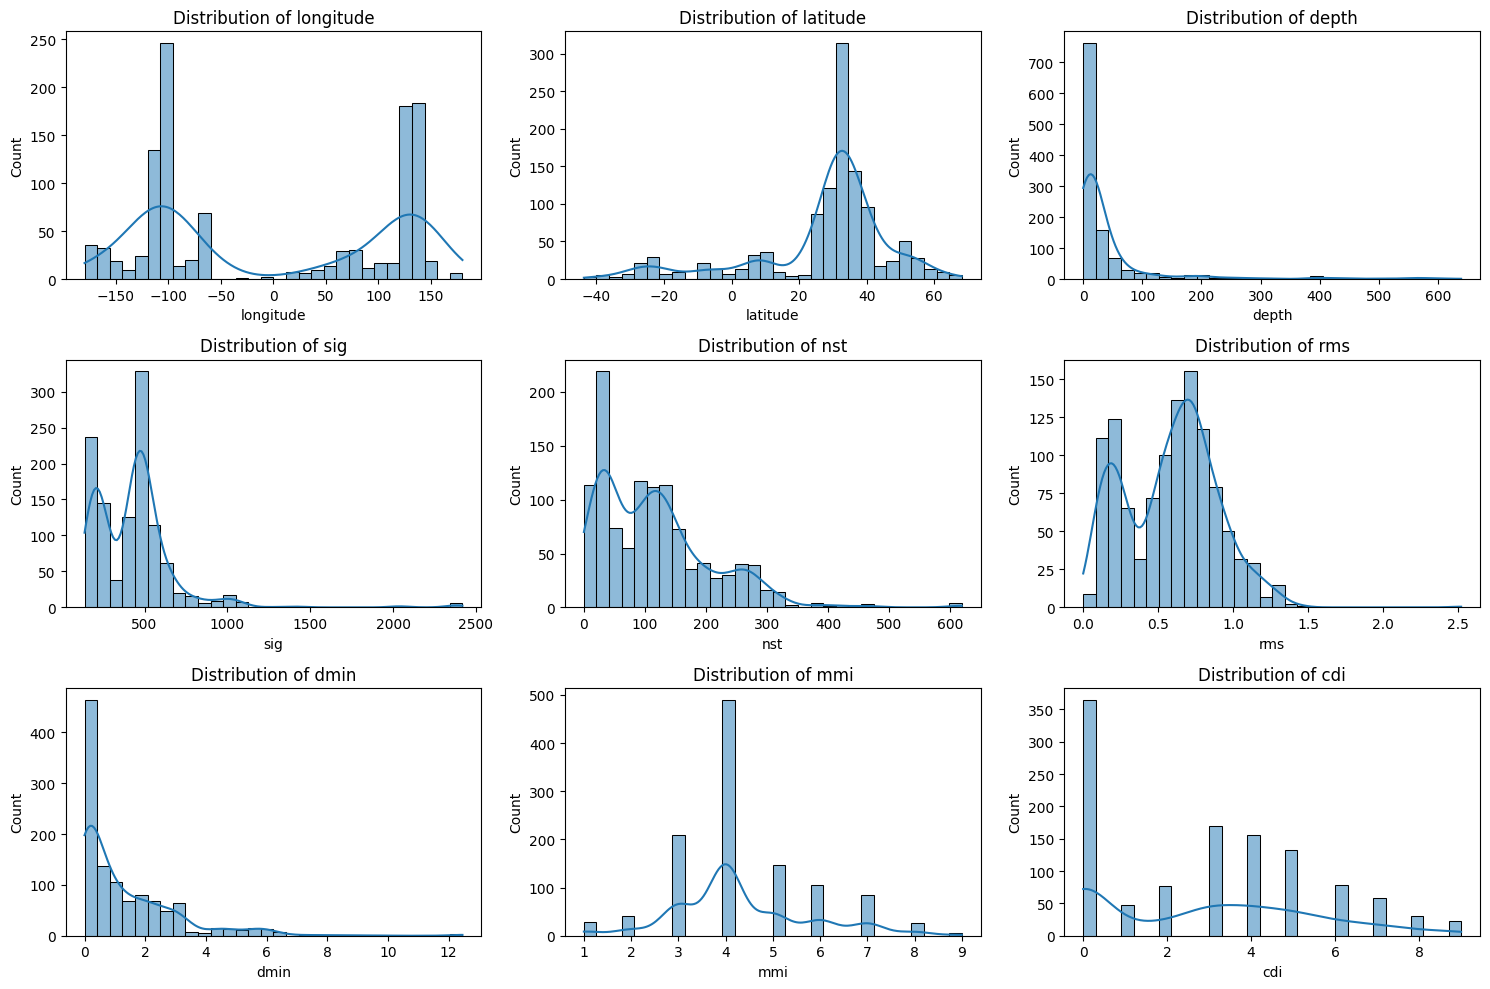

Value counts for alert:
 alert
green      711
unknown    373
yellow      38
red          9
orange       6
Name: count, dtype: int64
Value counts for status:
 status
reviewed     1127
automatic       6
REVIEWED        4
Name: count, dtype: int64
Value counts for magType:
 magType
mww      551
ml       351
mb       124
mwr       53
mw        36
mb_lg     16
mwb        2
Ml         2
Mi         2
Name: count, dtype: int64
Value counts for continent:
 continent
North America      446
Asia               333
unknown            270
South America       75
Europe               7
Africa               3
Insular Oceania      1
Insluar Oceania      1
Oceania              1
Name: count, dtype: int64
Gradient Boosting - MAE: 0.06855134759793984 MSE: 0.012424519350364626
Random Forest - MAE: 0.037837719298247585 MSE: 0.007298419736842115
Le modèle Random Forest est le meilleur.


In [2]:
# Importer les bibliothèques nécessaires
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chargement et exploration des données
data = pd.read_csv('../data/earthquakes.csv')

# Afficher un aperçu des données
print("Shape of data:", data.shape)
print("Columns:", data.columns)
print(data.head())
print(data.info())

# 2. Prétraitement des données
# Colonnes sélectionnées
selected_columns = [
    'magnitude', 'longitude', 'latitude', 'depth', 'sig', 'nst', 'rms',
    'dmin', 'mmi', 'cdi', 'alert', 'status', 'magType', 'continent'
]
data = data[selected_columns]

# Traitement des valeurs manquantes
numeric_cols = ['longitude', 'latitude', 'depth', 'sig', 'nst', 'rms', 'dmin', 'mmi', 'cdi']
categorical_cols = ['alert', 'status', 'magType', 'continent']

data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
data[categorical_cols] = data[categorical_cols].fillna('unknown')

# 3. Analyse exploratoire des données
# Analyse descriptive
print(data.describe())

# Visualisation des distributions des colonnes numériques
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Analyse des colonnes catégoriques
for col in categorical_cols:
    print(f"Value counts for {col}:\n", data[col].value_counts())

# 4. Transformation des données
# Encodage des colonnes catégoriques
encoded_data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# 5. Division des données en ensembles d'entraînement et de test
X = encoded_data.drop('magnitude', axis=1)
y = encoded_data['magnitude']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Construction et entraînement des modèles
# Modèle Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# Modèle Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# 7. Évaluation des modèles
# Prédictions
gb_preds = gb_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Calcul des métriques
gb_mae = mean_absolute_error(y_test, gb_preds)
gb_mse = mean_squared_error(y_test, gb_preds)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mse = mean_squared_error(y_test, rf_preds)

print("Gradient Boosting - MAE:", gb_mae, "MSE:", gb_mse)
print("Random Forest - MAE:", rf_mae, "MSE:", rf_mse)

# 8. Sélection du meilleur modèle
if rf_mae < gb_mae:
    print("Le modèle Random Forest est le meilleur.")
else:
    print("Le modèle Gradient Boosting est le meilleur.")

Shape of data: (1137, 43)
Columns: Index(['id', 'magnitude', 'type', 'title', 'date', 'time', 'updated', 'url',
       'detailUrl', 'felt', 'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig',
       'net', 'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms', 'gap',
       'magType', 'geometryType', 'depth', 'latitude', 'longitude', 'place',
       'distanceKM', 'placeOnly', 'location', 'continent', 'country',
       'subnational', 'city', 'locality', 'postcode', 'what3words', 'timezone',
       'locationDetails'],
      dtype='object')
           id  magnitude        type  \
0  us7000necw        4.8  earthquake   
1  tx2024shcj        5.1  earthquake   
2  ci40734823        3.7  earthquake   
3  tx2024scvz        3.9  earthquake   
4  us7000ndte        4.1  earthquake   

                                        title                 date  \
0         M 4.8 - 33 km WSW of Ackerly, Texas  2024-09-17T00:49:42   
1         M 5.1 - 34 km WSW of Ackerly, Texas  2024-09-17T00:49:42   
2   

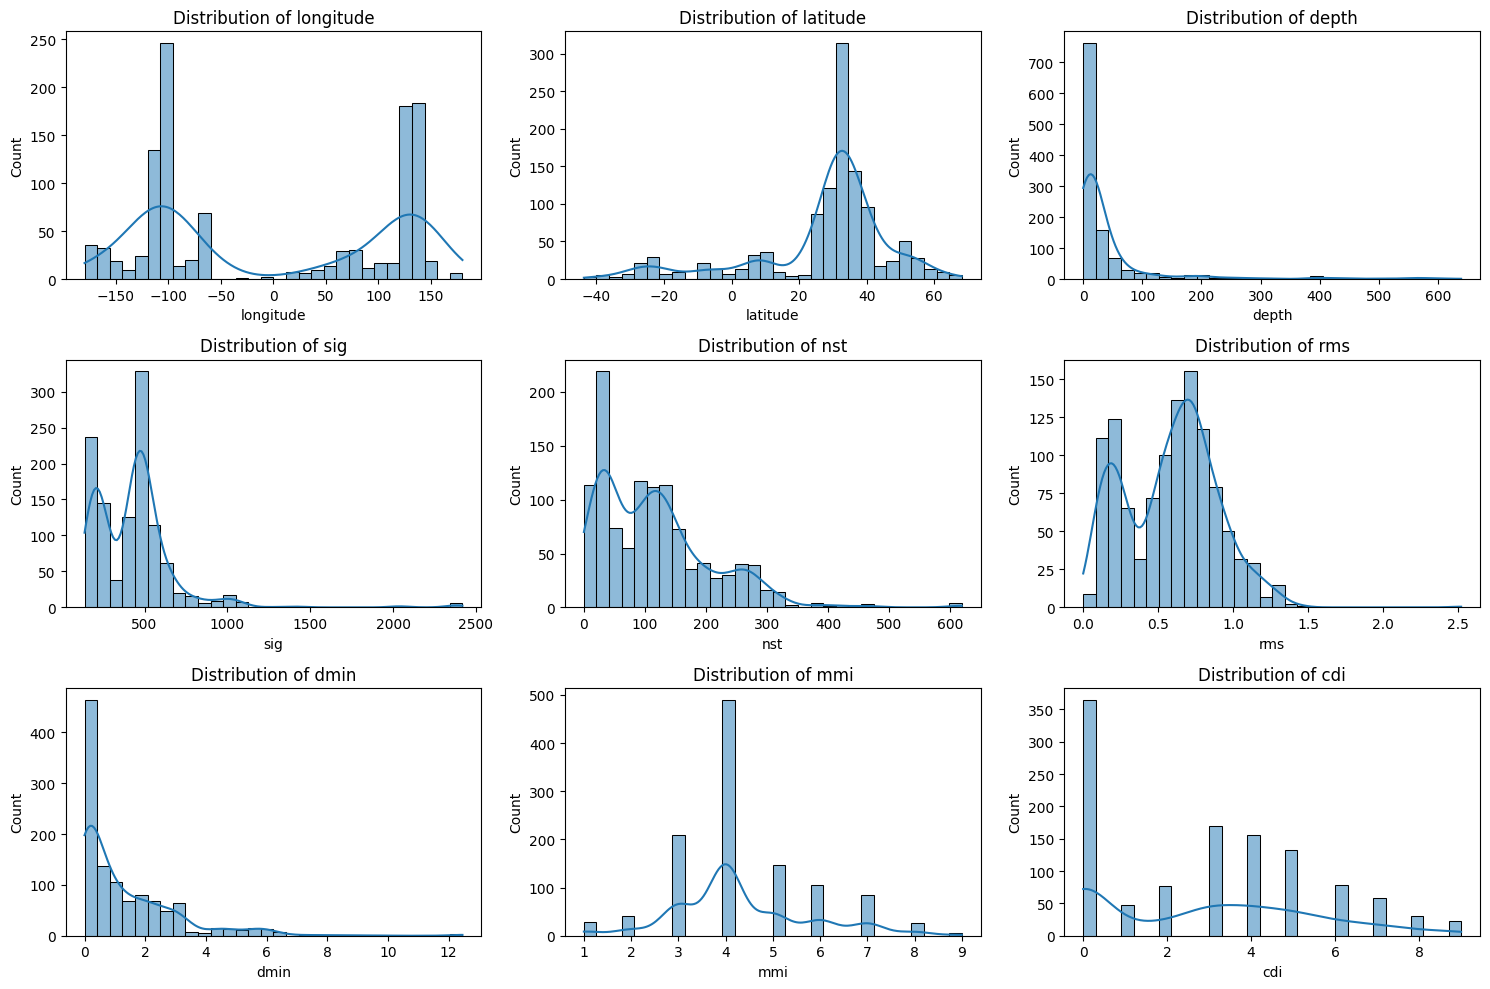

Value counts for alert:
 alert
green      711
unknown    373
yellow      38
red          9
orange       6
Name: count, dtype: int64
Value counts for status:
 status
reviewed     1127
automatic       6
REVIEWED        4
Name: count, dtype: int64
Value counts for magType:
 magType
mww      551
ml       351
mb       124
mwr       53
mw        36
mb_lg     16
mwb        2
Ml         2
Mi         2
Name: count, dtype: int64
Value counts for continent:
 continent
North America      446
Asia               333
unknown            270
South America       75
Europe               7
Africa               3
Insular Oceania      1
Insluar Oceania      1
Oceania              1
Name: count, dtype: int64


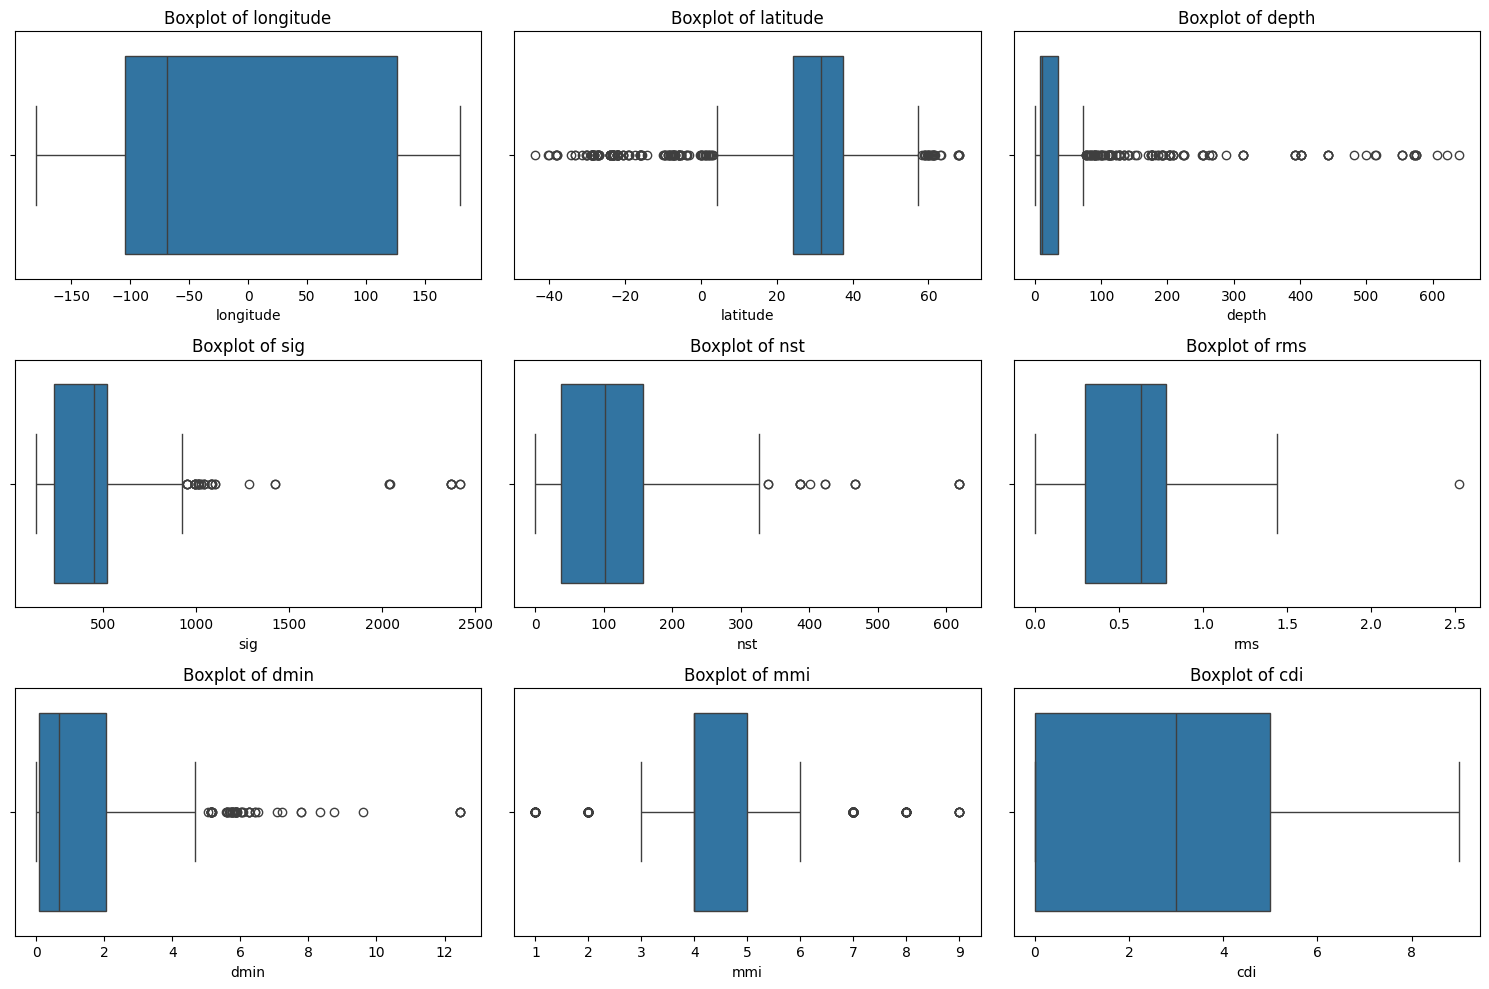

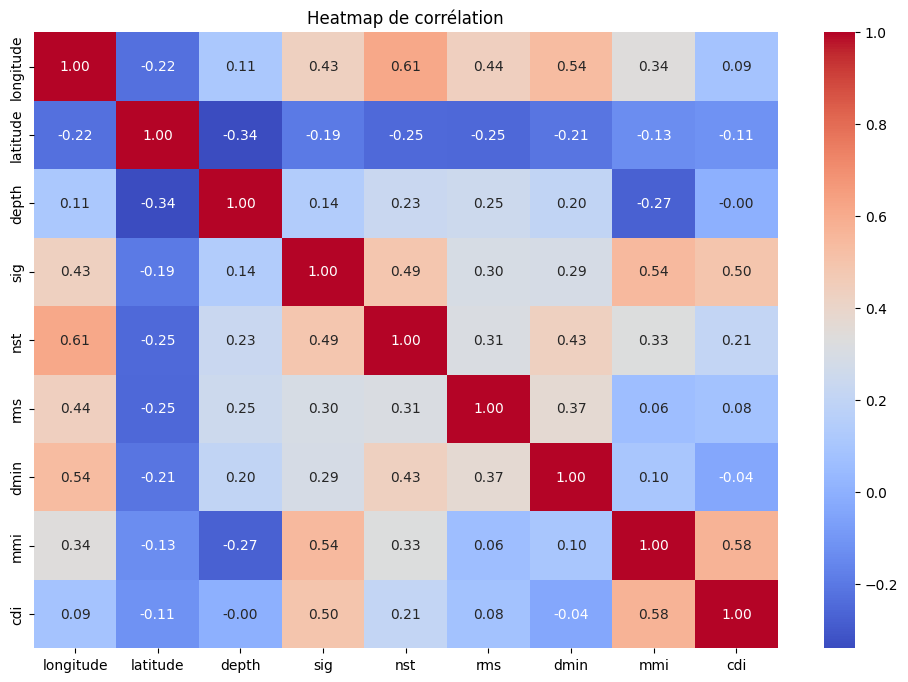

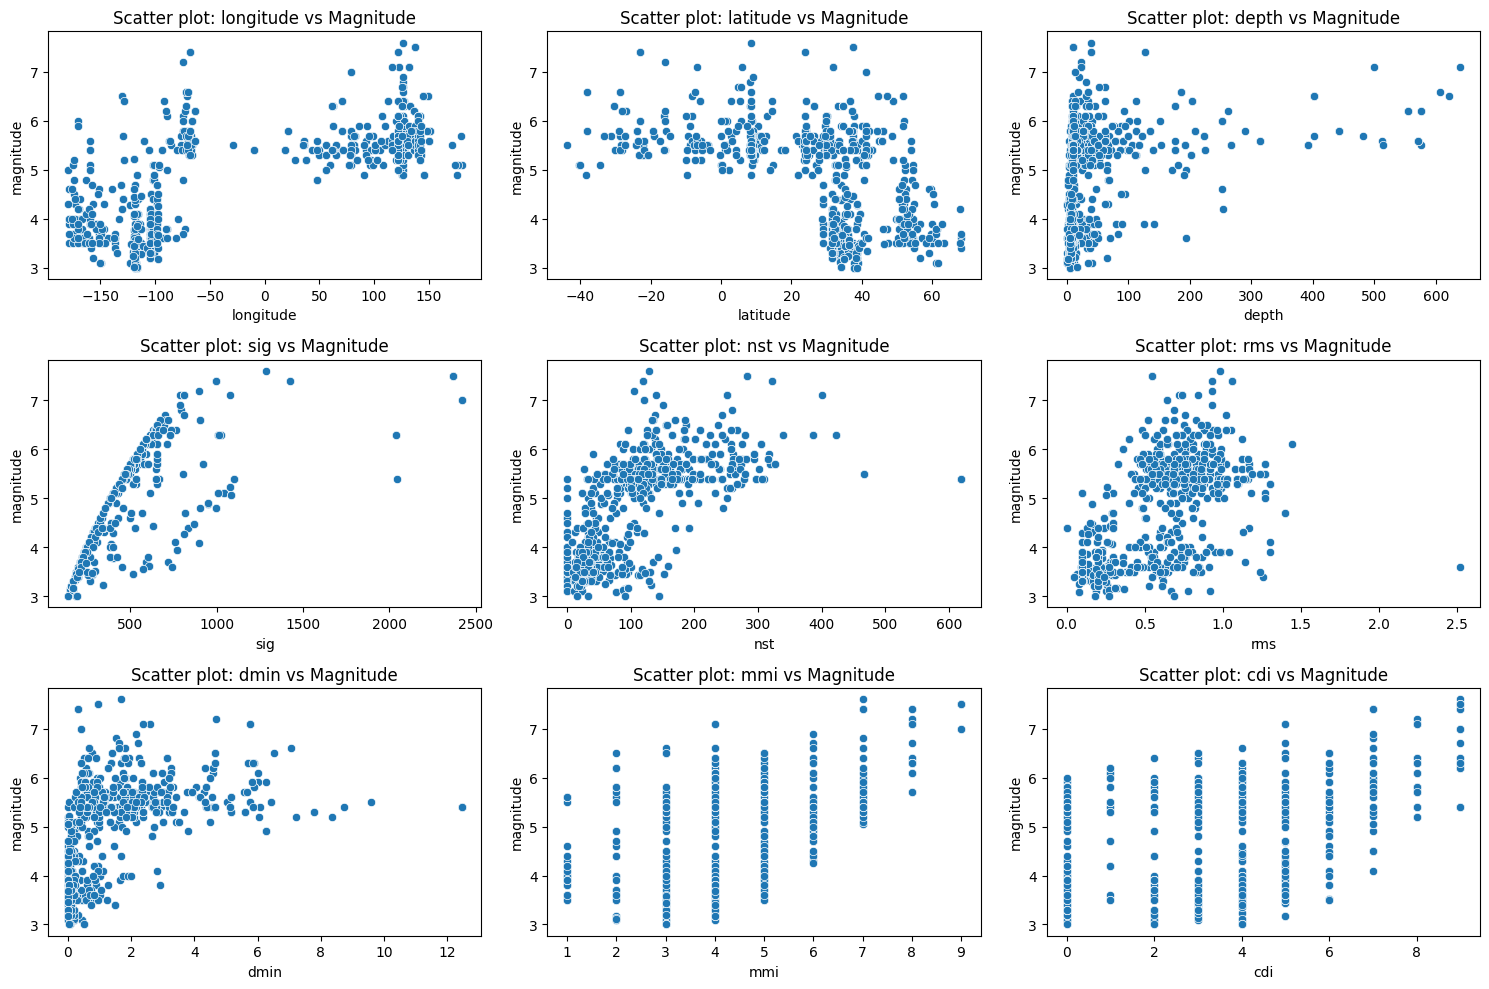

Gradient Boosting - MAE: 0.06855134759793984 MSE: 0.012424519350364626
Random Forest - MAE: 0.037837719298247585 MSE: 0.007298419736842115
Le modèle Random Forest est le meilleur.


In [3]:
# Importer les bibliothèques nécessaires
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chargement et exploration des données
data = pd.read_csv('../data/earthquakes.csv')

# Afficher un aperçu des données
print("Shape of data:", data.shape)
print("Columns:", data.columns)
print(data.head())
print(data.info())

# 2. Prétraitement des données
# Colonnes sélectionnées
selected_columns = [
    'magnitude', 'longitude', 'latitude', 'depth', 'sig', 'nst', 'rms',
    'dmin', 'mmi', 'cdi', 'alert', 'status', 'magType', 'continent'
]
data = data[selected_columns]

# Traitement des valeurs manquantes
numeric_cols = ['longitude', 'latitude', 'depth', 'sig', 'nst', 'rms', 'dmin', 'mmi', 'cdi']
categorical_cols = ['alert', 'status', 'magType', 'continent']

data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
data[categorical_cols] = data[categorical_cols].fillna('unknown')

# 3. Analyse exploratoire des données
# Analyse descriptive
print(data.describe())

# Visualisation des distributions des colonnes numériques
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Analyse des colonnes catégoriques
for col in categorical_cols:
    print(f"Value counts for {col}:\n", data[col].value_counts())

# Boxplot pour les colonnes numériques
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Heatmap de corrélation
plt.figure(figsize=(12, 8))
correlation_matrix = data[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap de corrélation')
plt.show()

# Scatter plots entre magnitude et autres colonnes numériques
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=data[col], y=data['magnitude'])
    plt.title(f'Scatter plot: {col} vs Magnitude')
plt.tight_layout()
plt.show()

# 4. Transformation des données
# Encodage des colonnes catégoriques
encoded_data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# 5. Division des données en ensembles d'entraînement et de test
X = encoded_data.drop('magnitude', axis=1)
y = encoded_data['magnitude']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Construction et entraînement des modèles
# Modèle Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# Modèle Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# 7. Évaluation des modèles
# Prédictions
gb_preds = gb_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Calcul des métriques
gb_mae = mean_absolute_error(y_test, gb_preds)
gb_mse = mean_squared_error(y_test, gb_preds)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mse = mean_squared_error(y_test, rf_preds)

print("Gradient Boosting - MAE:", gb_mae, "MSE:", gb_mse)
print("Random Forest - MAE:", rf_mae, "MSE:", rf_mse)

# 8. Sélection du meilleur modèle
if rf_mae < gb_mae:
    print("Le modèle Random Forest est le meilleur.")
else:
    print("Le modèle Gradient Boosting est le meilleur.")